by: Daniela Lavanderos, Victor Camero

In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import plot_tree
import pandas as pd


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/dalark/.local/lib/python3.13/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/dalark/.local/lib/python3.13/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/dalark/.local/lib/python3.13/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/dalark/.local/

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



In [2]:
dataset_el_pino = pd.read_csv("../data/dataModelCSV/label_encoding.csv", sep=";")
dataset_el_pino.head()

,Diag 01 Principal (cod+des),Diag 02 Secundario (cod+des),Diag 03 Secundario (cod+des),Diag 04 Secundario (cod+des),Diag 05 Secundario (cod+des),Diag 06 Secundario (cod+des),Diag 07 Secundario (cod+des),Diag 08 Secundario (cod+des),Diag 09 Secundario (cod+des),Diag 10 Secundario (cod+des),...,Proced 24 Secundario (cod+des),Proced 25 Secundario (cod+des),Proced 26 Secundario (cod+des),Proced 27 Secundario (cod+des),Proced 28 Secundario (cod+des),Proced 29 Secundario (cod+des),Proced 30 Secundario (cod+des),Edad en años,Sexo (Desc),GRD
0,24,41,373,638,38,462,391,26,6,242,...,112,19,40,40,41,39,13,40,1,135
1,1364,508,1016,889,796,833,693,297,260,244,...,57,42,53,40,39,73,39,53,1,14
2,575,1177,1051,452,975,330,649,23,31,9,...,112,54,44,99,22,26,26,65,1,14
3,622,670,711,120,169,149,321,411,251,411,...,18,1,3,90,90,82,86,61,1,15
4,1342,1571,1102,964,923,362,297,574,491,349,...,46,53,51,72,88,73,9,30,1,15


In [3]:
rows, columns = dataset_el_pino.shape
rows

14278

In [4]:
delete_rows = [["GRD"], # Modelo 1 y 2
              ["GRD", "Edad en años", "Sexo (Desc)"], # Modelo 3 y 4
               ['Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 Secundario (cod+des)',
 'Diag 32 Secundario (cod+des)',
 'Diag 33 Secundario (cod+des)',
 'Diag 34 Secundario (cod+des)',
 'Diag 35 Secundario (cod+des)','Proced 06 Secundario (cod+des)',
 'Proced 07 Secundario (cod+des)',
 'Proced 08 Secundario (cod+des)',
 'Proced 09 Secundario (cod+des)',
 'Proced 10 Secundario (cod+des)',
 'Proced 11 Secundario (cod+des)',
 'Proced 12 Secundario (cod+des)',
 'Proced 13 Secundario (cod+des)',
 'Proced 14 Secundario (cod+des)',
 'Proced 15 Secundario (cod+des)',
 'Proced 16 Secundario (cod+des)',
 'Proced 17 Secundario (cod+des)',
 'Proced 18 Secundario (cod+des)',
 'Proced 19 Secundario (cod+des)',
 'Proced 20 Secundario (cod+des)',
 'Proced 21 Secundario (cod+des)',
 'Proced 22 Secundario (cod+des)',
 'Proced 23 Secundario (cod+des)',
 'Proced 24 Secundario (cod+des)',
 'Proced 25 Secundario (cod+des)',
 'Proced 26 Secundario (cod+des)',
 'Proced 27 Secundario (cod+des)',
 'Proced 28 Secundario (cod+des)',
 'Proced 29 Secundario (cod+des)',
 'Proced 30 Secundario (cod+des)', 'GRD'], # Model 5 y 6
               ['Diag 03 Secundario (cod+des)',
 'Diag 04 Secundario (cod+des)',
 'Diag 05 Secundario (cod+des)',
 'Diag 06 Secundario (cod+des)',
 'Diag 07 Secundario (cod+des)',
 'Diag 08 Secundario (cod+des)',
 'Diag 09 Secundario (cod+des)',
 'Diag 10 Secundario (cod+des)',
 'Diag 11 Secundario (cod+des)',
 'Diag 12 Secundario (cod+des)',
 'Diag 13 Secundario (cod+des)',
 'Diag 14 Secundario (cod+des)',
 'Diag 15 Secundario (cod+des)',
 'Diag 16 Secundario (cod+des)',
 'Diag 17 Secundario (cod+des)',
 'Diag 18 Secundario (cod+des)',
 'Diag 19 Secundario (cod+des)',
 'Diag 20 Secundario (cod+des)',
 'Diag 21 Secundario (cod+des)',
 'Diag 22 Secundario (cod+des)',
 'Diag 23 Secundario (cod+des)',
 'Diag 24 Secundario (cod+des)',
 'Diag 25 Secundario (cod+des)',
 'Diag 26 Secundario (cod+des)',
 'Diag 27 Secundario (cod+des)',
 'Diag 28 Secundario (cod+des)',
 'Diag 29 Secundario (cod+des)',
 'Diag 30 Secundario (cod+des)',
 'Diag 31 Secundario (cod+des)',
 'Diag 32 Secundario (cod+des)',
 'Diag 33 Secundario (cod+des)',
 'Diag 34 Secundario (cod+des)',
 'Diag 35 Secundario (cod+des)','Proced 06 Secundario (cod+des)',
 'Proced 07 Secundario (cod+des)',
 'Proced 08 Secundario (cod+des)',
 'Proced 09 Secundario (cod+des)',
 'Proced 10 Secundario (cod+des)',
 'Proced 11 Secundario (cod+des)',
 'Proced 12 Secundario (cod+des)',
 'Proced 13 Secundario (cod+des)',
 'Proced 14 Secundario (cod+des)',
 'Proced 15 Secundario (cod+des)',
 'Proced 16 Secundario (cod+des)',
 'Proced 17 Secundario (cod+des)',
 'Proced 18 Secundario (cod+des)',
 'Proced 19 Secundario (cod+des)',
 'Proced 20 Secundario (cod+des)',
 'Proced 21 Secundario (cod+des)',
 'Proced 22 Secundario (cod+des)',
 'Proced 23 Secundario (cod+des)',
 'Proced 24 Secundario (cod+des)',
 'Proced 25 Secundario (cod+des)',
 'Proced 26 Secundario (cod+des)',
 'Proced 27 Secundario (cod+des)',
 'Proced 28 Secundario (cod+des)',
 'Proced 29 Secundario (cod+des)',
 'Proced 30 Secundario (cod+des)', 'Sexo (Desc)', 'GRD']
              ]

# One shot

## Modelo 1

In [5]:
# 1. Definir las variables explicativas y el objetivo (igual que antes)
Explicativas_rf = dataset_el_pino.drop(columns=delete_rows[0])
Objetivo_rf = dataset_el_pino.GRD


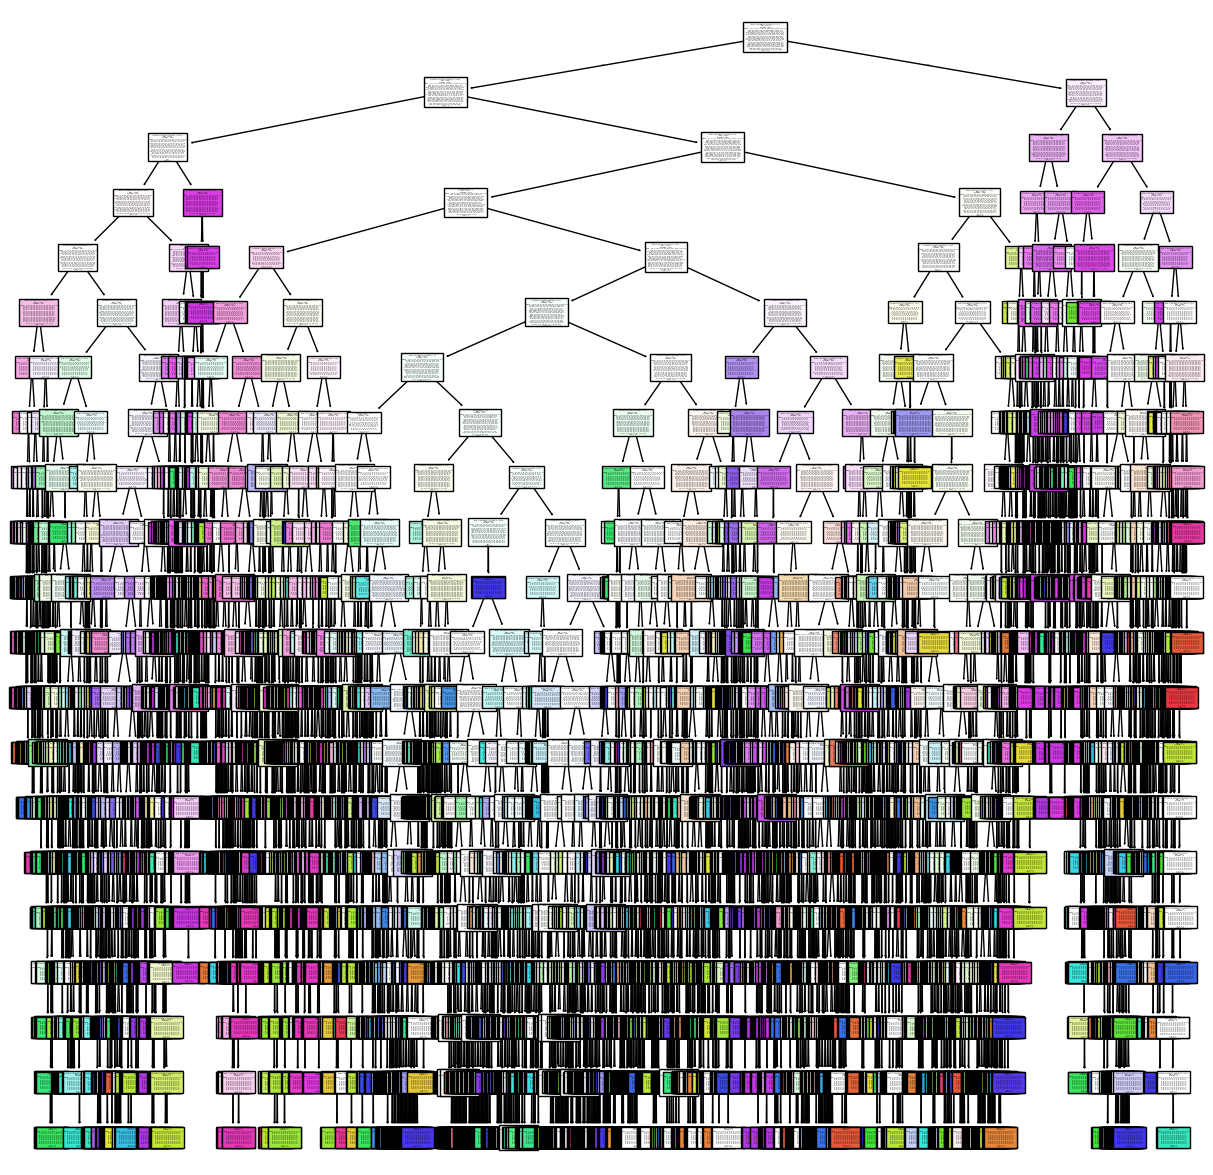

Ejemplo para predecir (Random Forest):
      Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
8206                         1247                          1411   

      Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
8206                           178                          1234   

      Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
8206                             0                             0   

      Diag 07 Secundario (cod+des)  Diag 08 Secundario (cod+des)  \
8206                             0                             0   

      Diag 09 Secundario (cod+des)  Diag 10 Secundario (cod+des)  ...  \
8206                             0                             0  ...   

      Proced 23 Secundario (cod+des)  Proced 24 Secundario (cod+des)  \
8206                               0                               0   

      Proced 25 Secundario (cod+des)  Proced 26 Secundario (cod+des)  \
8206                               0               

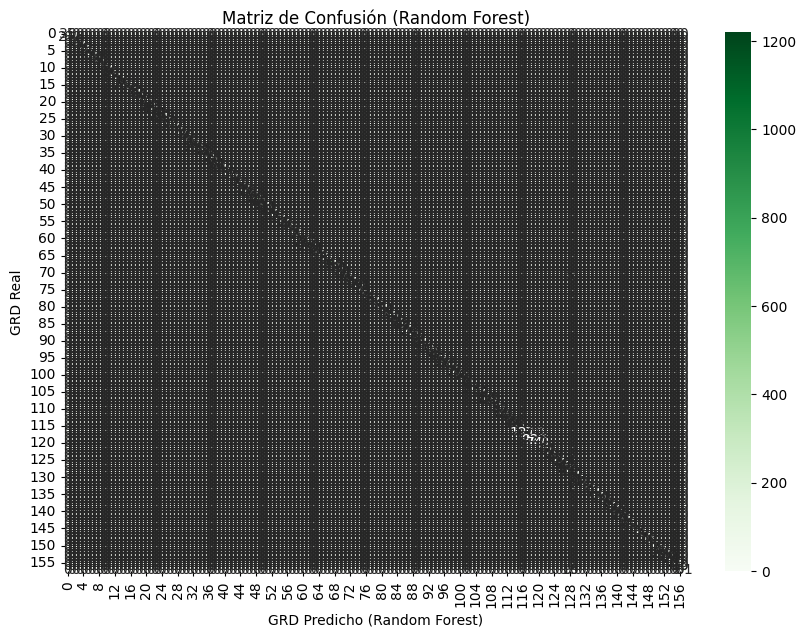

In [6]:
# 2. Crear e entrenar el modelo de Random Forest
# Puedes ajustar los hiperparámetros como 'n_estimators' (número de árboles),
# 'max_depth', 'random_state' para reproducibilidad, etc.
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf.fit(Explicativas_rf, Objetivo_rf)

# 3. Visualizar uno de los árboles
plt.figure(figsize=(15,15))
plot_tree(modelo_rf.estimators_[0], feature_names=Explicativas_rf.columns, class_names=Objetivo_rf.unique().astype(str), filled=True)
plt.show()
# 4. Realizar una predicción sobre un ejemplo (similar al árbol de decisión)
test_ejemplo_rf = Explicativas_rf.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf.predict_proba(test_ejemplo_rf))

# 5. Predecir sobre todo el conjunto de datos
predecir_grd_rf = modelo_rf.predict(Explicativas_rf)
print("\nPredicciones del Random Forest:")
print(predecir_grd_rf)

# 6. Evaluar el modelo: Matriz de confusión
matriz_confusion_rf = confusion_matrix(dataset_el_pino['GRD'], predecir_grd_rf)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf, annot=True, fmt="d", cmap="Greens") # Cambié el mapa de color para diferenciar
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()



In [7]:
# 7. Calcular el porcentaje de aciertos
porcentaje_rf = np.round(((dataset_el_pino['GRD'] == predecir_grd_rf).sum())/len(dataset_el_pino) * 100, decimals=2) # Usé len() en lugar de 'rows' por seguridad
print(f"\nPorcentaje del modelo Random Forest: {porcentaje_rf}%")


Porcentaje del modelo Random Forest: 99.82%


In [8]:
def medir_modelos(predecir):
    # Calcular accuracy
    accuracy = accuracy_score(dataset_el_pino['GRD'], predecir) * 100
    print(f"Accuracy: {accuracy:.2f}%")
    
    # Calcular precision
    precision = precision_score(dataset_el_pino['GRD'], predecir, average='macro', zero_division=0) * 100
    print(f"Precision (macro): {precision:.2f}%")
    
    # Calcular recall
    recall = recall_score(dataset_el_pino['GRD'], predecir, average='macro', zero_division=0) * 100
    print(f"Recall (macro): {recall:.2f}%")

In [9]:
# 8. Utilizar la función para medir el modelo
print("Métricas del modelo Random Forest:")
medir_modelos(predecir_grd_rf)

Métricas del modelo Random Forest:
Accuracy: 99.82%
Precision (macro): 99.96%
Recall (macro): 99.78%


## Modelo 2

In [10]:
Explicativas_rf2 = dataset_el_pino.drop(columns=delete_rows[1])
Objetivo_rf2 = dataset_el_pino.GRD

In [11]:
modelo_rf2 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf2.fit(Explicativas_rf2, Objetivo_rf2)

# 3. (Opcional) Visualizar uno de los árboles del bosque
#plt.figure(figsize=(15,10))
#plot_tree(modelo_rf2.estimators_[0], feature_names=Explicativas_rf2.columns, class_names=Objetivo_rf2.unique().astype(str), filled=True)
#plt.show()


RandomForestClassifier(max_depth=20, random_state=42)

Ejemplo para predecir (Random Forest):
      Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
1509                          871                             0   

      Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
1509                             0                             0   

      Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
1509                             0                             0   

      Diag 07 Secundario (cod+des)  Diag 08 Secundario (cod+des)  \
1509                             0                             0   

      Diag 09 Secundario (cod+des)  Diag 10 Secundario (cod+des)  ...  \
1509                             0                             0  ...   

      Proced 21 Secundario (cod+des)  Proced 22 Secundario (cod+des)  \
1509                               0                               0   

      Proced 23 Secundario (cod+des)  Proced 24 Secundario (cod+des)  \
1509                               0               

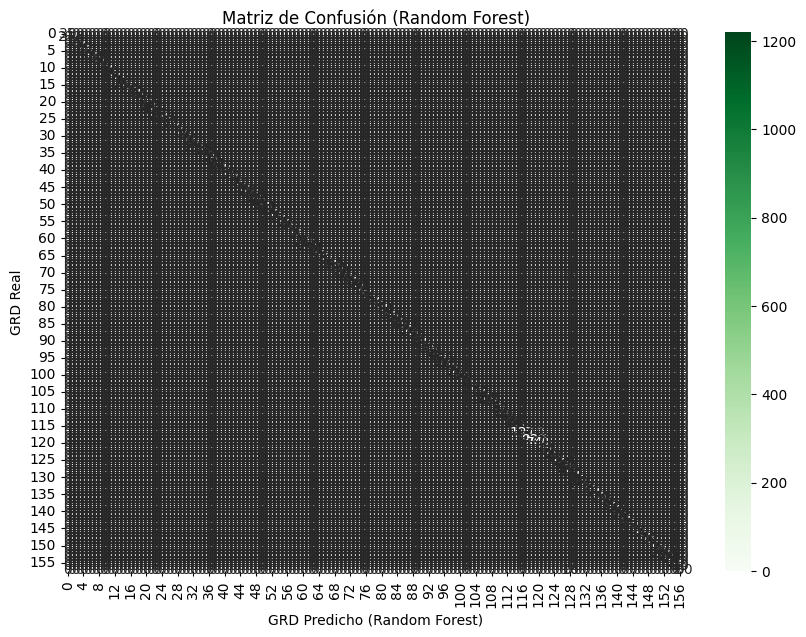

In [12]:

# 4. Realizar una predicción sobre un ejemplo (similar al árbol de decisión)
test_ejemplo_rf2 = Explicativas_rf2.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf2)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf2.predict_proba(test_ejemplo_rf2))

# 5. Predecir sobre todo el conjunto de datos
predecir_grd_rf2 = modelo_rf2.predict(Explicativas_rf2)
print("\nPredicciones del Random Forest:")
print(predecir_grd_rf2)

# 6. Evaluar el modelo: Matriz de confusión
matriz_confusion_rf2 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd_rf2)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf2, annot=True, fmt="d", cmap="Greens") # Cambié el mapa de color para diferenciar
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

In [13]:
# 7. Calcular el porcentaje de aciertos
porcentaje_rf2 = np.round(((dataset_el_pino['GRD'] == predecir_grd_rf2).sum())/len(dataset_el_pino) * 100, decimals=2) # Usé len() en lugar de 'rows' por seguridad
print(f"\nPorcentaje del modelo Random Forest: {porcentaje_rf2}%")


Porcentaje del modelo Random Forest: 99.77%


In [14]:
print("Métricas del modelo Random Forest:")
medir_modelos(predecir_grd_rf2)

Métricas del modelo Random Forest:
Accuracy: 99.77%
Precision (macro): 99.95%
Recall (macro): 99.74%


## Modelo 3

In [15]:
# 1. Definir las variables explicativas y el objetivo (igual que antes)
Explicativas_rf3 = dataset_el_pino.drop(columns=delete_rows[2])
Objetivo_rf3 = dataset_el_pino.GRD

Ejemplo para predecir (Random Forest):
       Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
11905                            9                           260   

       Proced 01 Principal (cod+des)  Proced 02 Secundario (cod+des)  \
11905                            389                             389   

       Proced 03 Secundario (cod+des)  Proced 04 Secundario (cod+des)  \
11905                             274                             264   

       Proced 05 Secundario (cod+des)  Edad en años  Sexo (Desc)  
11905                             243            33            0  

Probabilidades de predicción (Random Forest):
[[0.00000000e+00 6.99300699e-05 2.27272727e-04 0.00000000e+00
  6.67368230e-04 1.94174757e-04 0.00000000e+00 3.70370370e-04
  0.00000000e+00 0.00000000e+00 0.00000000e+00 2.79720280e-04
  1.36054422e-04 0.00000000e+00 0.00000000e+00 9.70873786e-05
  0.00000000e+00 0.00000000e+00 0.00000000e+00 2.09790210e-04
  5.44217687e-04 4.28686129e-03 1.9735442

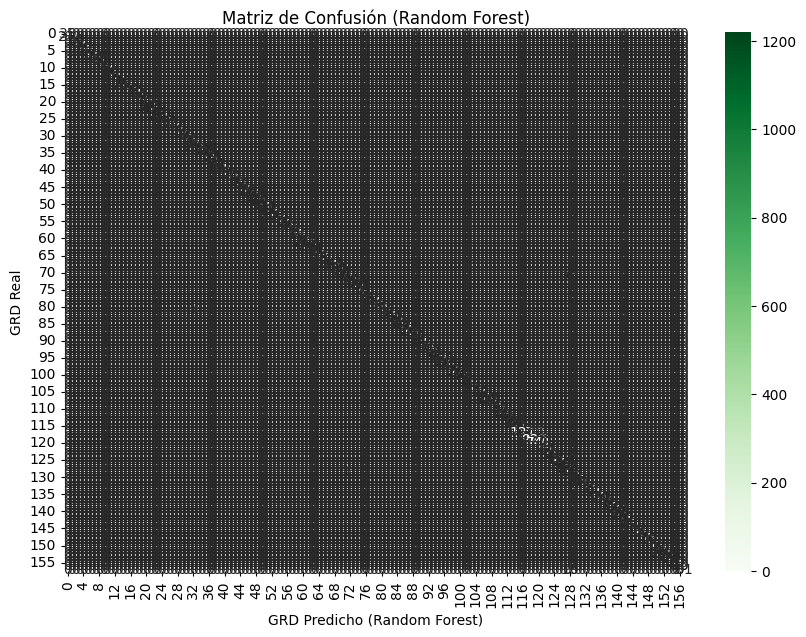

In [16]:

# 2. Crear e entrenar el modelo de Random Forest
# Puedes ajustar los hiperparámetros como 'n_estimators' (número de árboles),
# 'max_depth', 'random_state' para reproducibilidad, etc.
modelo_rf3 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf3.fit(Explicativas_rf3, Objetivo_rf3)

# 3. (Opcional) Visualizar uno de los árboles del bosque
#plt.figure(figsize=(15,10))
#plot_tree(modelo_rf.estimators_[0], feature_names=Explicativas_rf.columns, class_names=Objetivo_rf.unique().astype(str), filled=True)
#plt.show()

# 4. Realizar una predicción sobre un ejemplo (similar al árbol de decisión)
test_ejemplo_rf3 = Explicativas_rf3.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf3)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf3.predict_proba(test_ejemplo_rf3))

# 5. Predecir sobre todo el conjunto de datos
predecir_grd_rf3 = modelo_rf3.predict(Explicativas_rf3)
print("\nPredicciones del Random Forest:")
print(predecir_grd_rf3)

# 6. Evaluar el modelo: Matriz de confusión
matriz_confusion_rf3 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd_rf3)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf3, annot=True, fmt="d", cmap="Greens") # Cambié el mapa de color para diferenciar
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

In [17]:
# 7. Calcular el porcentaje de aciertos
porcentaje_rf3 = np.round(((dataset_el_pino['GRD'] == predecir_grd_rf3).sum())/len(dataset_el_pino) * 100, decimals=2) # Usé len() en lugar de 'rows' por seguridad
print(f"\nPorcentaje del modelo Random Forest: {porcentaje_rf3}%")


Porcentaje del modelo Random Forest: 99.8%


In [18]:
print("Métricas del modelo Random Forest:")
medir_modelos(predecir_grd_rf3)

Métricas del modelo Random Forest:
Accuracy: 99.80%
Precision (macro): 99.92%
Recall (macro): 99.73%


## Modelo 4

In [19]:
# 1. Definir las variables explicativas y el objetivo (igual que antes)
Explicativas_rf4 = dataset_el_pino.drop(columns=delete_rows[3])
Objetivo_rf4 = dataset_el_pino.GRD

Ejemplo para predecir (Random Forest):
       Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
14052                          880                          1003   

       Proced 01 Principal (cod+des)  Proced 02 Secundario (cod+des)  \
14052                            318                             368   

       Proced 03 Secundario (cod+des)  Proced 04 Secundario (cod+des)  \
14052                             359                             266   

       Proced 05 Secundario (cod+des)  Edad en años  
14052                             153            30  

Probabilidades de predicción (Random Forest):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.
  0. 0.

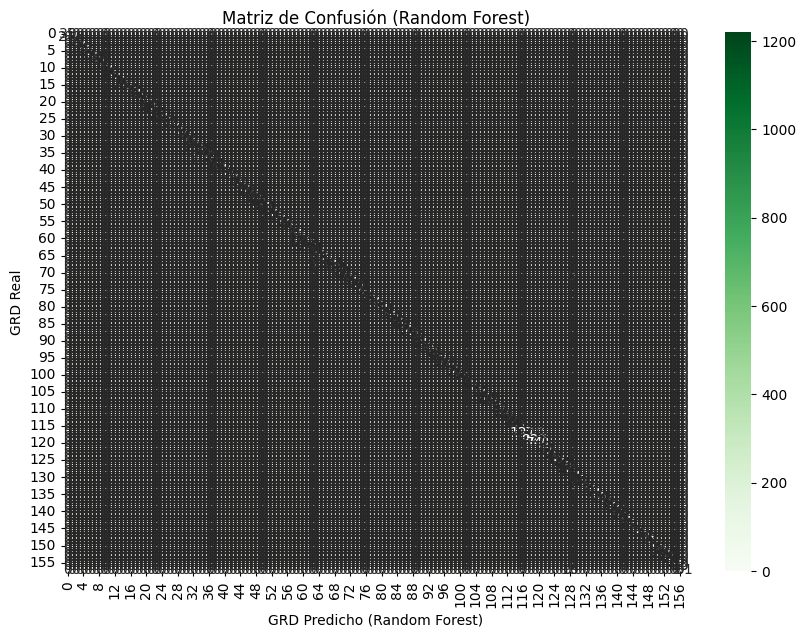

In [20]:

# 2. Crear e entrenar el modelo de Random Forest
# Puedes ajustar los hiperparámetros como 'n_estimators' (número de árboles),
# 'max_depth', 'random_state' para reproducibilidad, etc.
modelo_rf4 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf4.fit(Explicativas_rf4, Objetivo_rf4)

# 3. (Opcional) Visualizar uno de los árboles del bosque
#plt.figure(figsize=(15,10))
#plot_tree(modelo_rf.estimators_[0], feature_names=Explicativas_rf.columns, class_names=Objetivo_rf.unique().astype(str), filled=True)
#plt.show()

# 4. Realizar una predicción sobre un ejemplo (similar al árbol de decisión)
test_ejemplo_rf4 = Explicativas_rf4.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf4)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf4.predict_proba(test_ejemplo_rf4))

# 5. Predecir sobre todo el conjunto de datos
predecir_grd_rf4 = modelo_rf4.predict(Explicativas_rf4)
print("\nPredicciones del Random Forest:")
print(predecir_grd_rf4)

# 6. Evaluar el modelo: Matriz de confusión
matriz_confusion_rf4 = confusion_matrix(dataset_el_pino['GRD'], predecir_grd_rf4)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf4, annot=True, fmt="d", cmap="Greens") # Cambié el mapa de color para diferenciar
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

In [21]:
print("Métricas del modelo Random Forest:")
medir_modelos(predecir_grd_rf4)

Métricas del modelo Random Forest:
Accuracy: 99.77%
Precision (macro): 99.85%
Recall (macro): 99.57%


# 70 30

## Modelo 1

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [23]:
# 1. Dividir los datos (70% entrenamiento / 30% prueba)
Explicativas_rf = dataset_el_pino.drop(columns=delete_rows[0])
Objetivo_rf = dataset_el_pino.GRD

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(Explicativas_rf, Objetivo_rf, test_size=0.3, random_state=42)

In [24]:
# 2. Crear y entrenar el modelo Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf.fit(X_train_rf, y_train_rf)

RandomForestClassifier(max_depth=20, random_state=42)

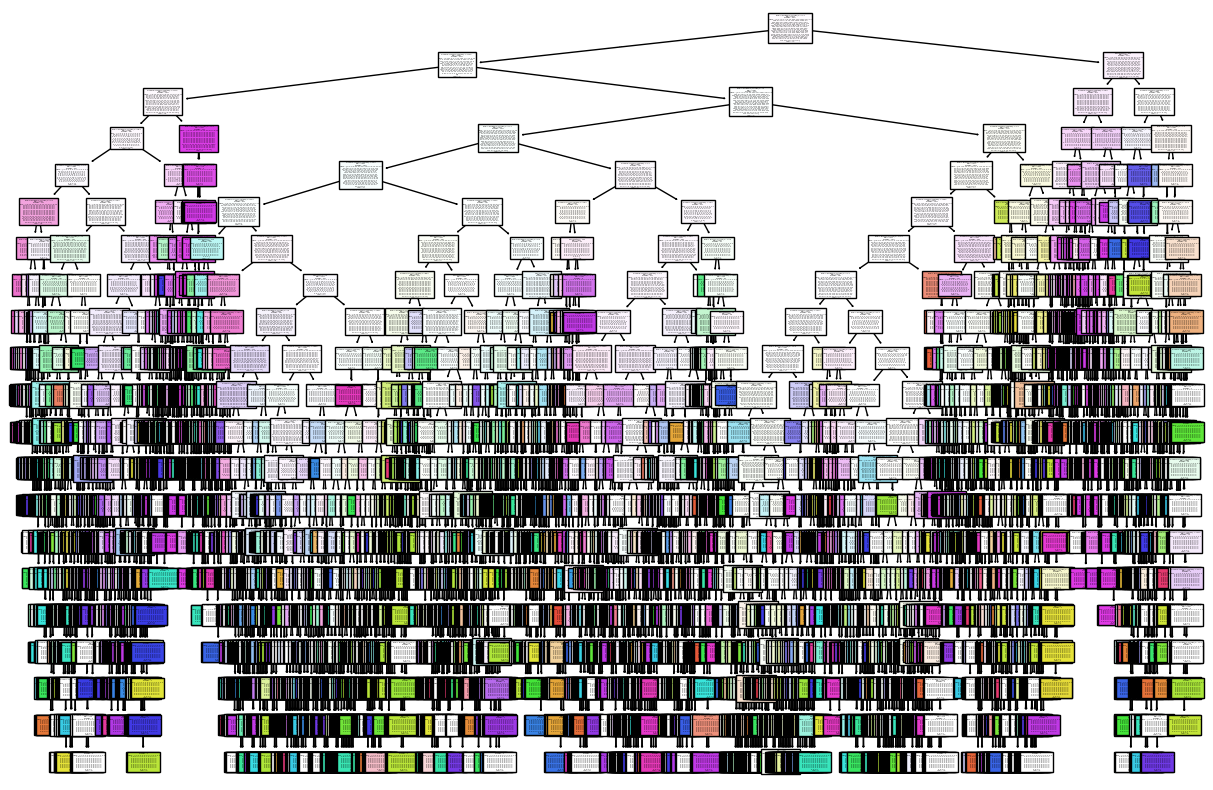

In [26]:
# 3. Visualizar uno de los árboles
plt.figure(figsize=(15,10))
plot_tree(modelo_rf.estimators_[0], feature_names=Explicativas_rf.columns, class_names=Objetivo_rf.unique().astype(str), filled=True)
plt.show()

In [27]:
# 4. Predicción sobre un ejemplo
test_ejemplo_rf = X_test_rf.sample()
print("Ejemplo para predecir (Random Forest):")
print(test_ejemplo_rf)
print("\nProbabilidades de predicción (Random Forest):")
print(modelo_rf.predict_proba(test_ejemplo_rf))

Ejemplo para predecir (Random Forest):
      Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
5107                          971                          1609   

      Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
5107                          1366                          1163   

      Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
5107                          1004                           854   

      Diag 07 Secundario (cod+des)  Diag 08 Secundario (cod+des)  \
5107                             0                             0   

      Diag 09 Secundario (cod+des)  Diag 10 Secundario (cod+des)  ...  \
5107                             0                             0  ...   

      Proced 23 Secundario (cod+des)  Proced 24 Secundario (cod+des)  \
5107                               0                               0   

      Proced 25 Secundario (cod+des)  Proced 26 Secundario (cod+des)  \
5107                               0               

In [28]:
# 5. Predicción sobre todo el conjunto de prueba
y_pred_rf = modelo_rf.predict(X_test_rf)
print("\nPredicciones del Random Forest:")
print(y_pred_rf)


Predicciones del Random Forest:
[140  32  62 ...  62  24   0]


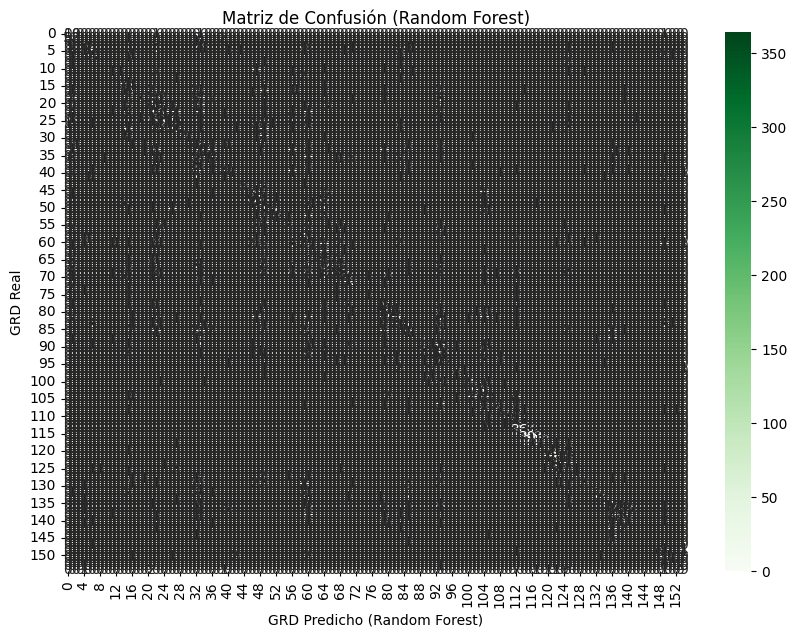

In [29]:
# 6. Evaluación con matriz de confusión
matriz_confusion_rf = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf, annot=True, fmt="d", cmap="Greens")
plt.xlabel('GRD Predicho (Random Forest)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest)')
plt.show()

In [30]:
# 7. Calcular porcentaje de aciertos
porcentaje_rf = np.round((accuracy_score(y_test_rf, y_pred_rf)) * 100, decimals=2)
print(f"\nPorcentaje del modelo Random Forest: {porcentaje_rf}%")
# Función para métricas
def medir_modelos(real, predicho):
    accuracy = accuracy_score(real, predicho) * 100
    print(f"Accuracy: {accuracy:.2f}%")
    
    precision = precision_score(real, predicho, average='macro', zero_division=0) * 100
    print(f"Precision (macro): {precision:.2f}%")
    
    recall = recall_score(real, predicho, average='macro', zero_division=0) * 100
    print(f"Recall (macro): {recall:.2f}%")
    
# 8. Evaluar con métricas
medir_modelos(y_test_rf, y_pred_rf)


Porcentaje del modelo Random Forest: 68.39%
Accuracy: 68.39%
Precision (macro): 34.05%
Recall (macro): 28.88%


## Modelo 2

In [31]:
# Modelo Random Forest 2: usando delete_rows[1]
Explicativas_rf2 = dataset_el_pino.drop(columns=delete_rows[1])
Objetivo_rf2 = dataset_el_pino.GRD

# División 70/30
X_train_rf2, X_test_rf2, y_train_rf2, y_test_rf2 = train_test_split(Explicativas_rf2, Objetivo_rf2, test_size=0.3, random_state=42)

In [32]:
# Entrenar el modelo Random Forest
modelo_rf2 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf2.fit(X_train_rf2, y_train_rf2)

RandomForestClassifier(max_depth=20, random_state=42)

In [33]:
# Predicción sobre ejemplo
test_ejemplo_rf2 = X_test_rf2.sample()
print("Ejemplo para predecir (Random Forest 2):")
print(test_ejemplo_rf2)
print("\nProbabilidades de predicción (Random Forest 2):")
print(modelo_rf2.predict_proba(test_ejemplo_rf2))

Ejemplo para predecir (Random Forest 2):
      Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
5871                          967                           985   

      Diag 03 Secundario (cod+des)  Diag 04 Secundario (cod+des)  \
5871                           792                           789   

      Diag 05 Secundario (cod+des)  Diag 06 Secundario (cod+des)  \
5871                           368                           846   

      Diag 07 Secundario (cod+des)  Diag 08 Secundario (cod+des)  \
5871                           715                           627   

      Diag 09 Secundario (cod+des)  Diag 10 Secundario (cod+des)  ...  \
5871                           544                           492  ...   

      Proced 21 Secundario (cod+des)  Proced 22 Secundario (cod+des)  \
5871                               0                               0   

      Proced 23 Secundario (cod+des)  Proced 24 Secundario (cod+des)  \
5871                               0             

In [34]:
# Predicción sobre el test completo
y_pred_rf2 = modelo_rf2.predict(X_test_rf2)
print("\nPredicciones del Random Forest 2:")
print(y_pred_rf2)


Predicciones del Random Forest 2:
[142  33 152 ...  62  24  40]


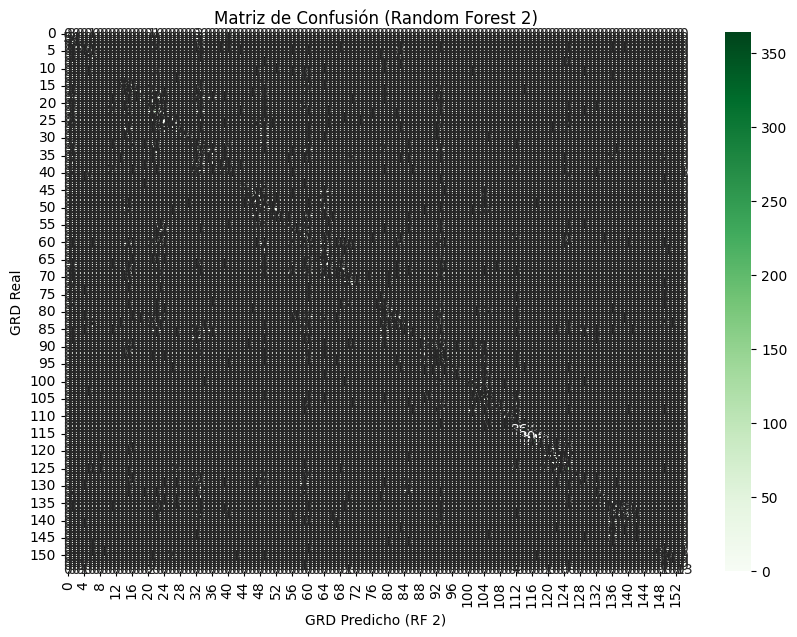

In [35]:
# Matriz de confusión
matriz_confusion_rf2 = confusion_matrix(y_test_rf2, y_pred_rf2)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf2, annot=True, fmt="d", cmap="Greens")
plt.xlabel('GRD Predicho (RF 2)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest 2)')
plt.show()

In [36]:
# Porcentaje de aciertos
porcentaje_rf2 = np.round((accuracy_score(y_test_rf2, y_pred_rf2)) * 100, decimals=2)
print(f"\nPorcentaje del modelo Random Forest 2: {porcentaje_rf2}%")

# Evaluación con métricas
medir_modelos(y_test_rf2, y_pred_rf2)


Porcentaje del modelo Random Forest 2: 67.86%
Accuracy: 67.86%
Precision (macro): 33.21%
Recall (macro): 27.30%


## Modelo 3

In [37]:
# Modelo Random Forest 3: 
Explicativas_rf3 = dataset_el_pino.drop(columns=delete_rows[2])
Objetivo_rf3 = dataset_el_pino.GRD

# División 70/30
X_train_rf3, X_test_rf3, y_train_rf3, y_test_rf3 = train_test_split(Explicativas_rf3, Objetivo_rf3, test_size=0.3, random_state=42)

In [38]:
# Entrenar el modelo Random Forest
modelo_rf3 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf3.fit(X_train_rf3, y_train_rf3)

RandomForestClassifier(max_depth=20, random_state=42)

In [39]:
# Predicción sobre ejemplo
test_ejemplo_rf3 = X_test_rf3.sample()
print("Ejemplo para predecir (Random Forest 3):")
print(test_ejemplo_rf3)
print("\nProbabilidades de predicción (Random Forest 3):")
print(modelo_rf3.predict_proba(test_ejemplo_rf3))

Ejemplo para predecir (Random Forest 3):
       Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
11183                          863                          1016   

       Proced 01 Principal (cod+des)  Proced 02 Secundario (cod+des)  \
11183                            414                             464   

       Proced 03 Secundario (cod+des)  Proced 04 Secundario (cod+des)  \
11183                             362                             262   

       Proced 05 Secundario (cod+des)  Edad en años  Sexo (Desc)  
11183                             163            25            0  

Probabilidades de predicción (Random Forest 3):
[[0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.
  0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   

In [40]:
# Predicción sobre el test completo
y_pred_rf3 = modelo_rf3.predict(X_test_rf3)
print("\nPredicciones del Random Forest 3:")
print(y_pred_rf3)


Predicciones del Random Forest 3:
[140  40  73 ...  62  24  18]


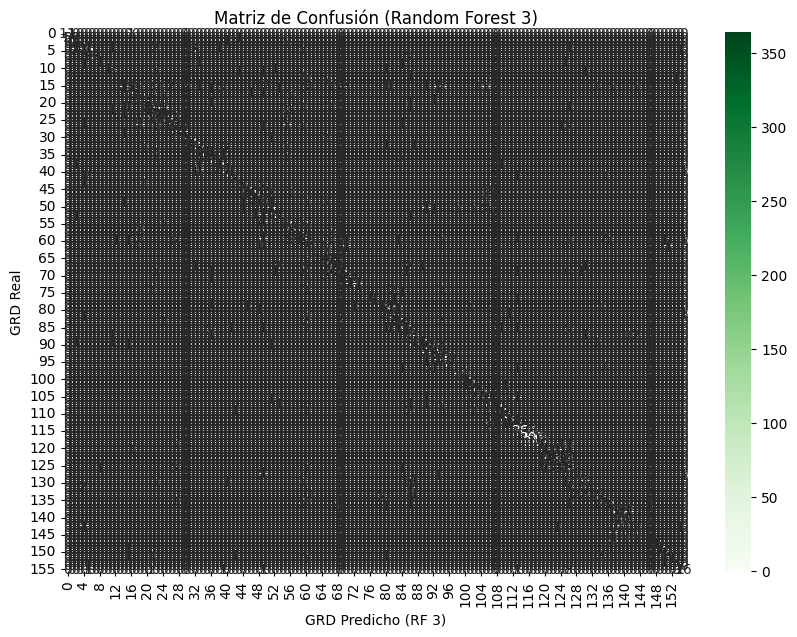

In [41]:
# Matriz de confusión
matriz_confusion_rf3 = confusion_matrix(y_test_rf3, y_pred_rf3)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf3, annot=True, fmt="d", cmap="Greens")
plt.xlabel('GRD Predicho (RF 3)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest 3)')
plt.show()

In [42]:
# Porcentaje de aciertos
porcentaje_rf3 = np.round((accuracy_score(y_test_rf3, y_pred_rf3)) * 100, decimals=2)
print(f"\nPorcentaje del modelo Random Forest 3: {porcentaje_rf3}%")

# Evaluación con métricas
medir_modelos(y_test_rf3, y_pred_rf3)


Porcentaje del modelo Random Forest 3: 84.29%
Accuracy: 84.29%
Precision (macro): 56.26%
Recall (macro): 53.97%


## Modelo 4

In [44]:
# Modelo Random Forest 4: usando delete_rows[3]
Explicativas_rf4 = dataset_el_pino.drop(columns=delete_rows[3])
Objetivo_rf4 = dataset_el_pino.GRD

# División 70/30
X_train_rf4, X_test_rf4, y_train_rf4, y_test_rf4 = train_test_split(Explicativas_rf4, Objetivo_rf4, test_size=0.3, random_state=42)

In [45]:
# Entrenar el modelo Random Forest
modelo_rf4 = RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42)
modelo_rf4.fit(X_train_rf4, y_train_rf4)

RandomForestClassifier(max_depth=20, random_state=42)

In [46]:
# Predicción sobre ejemplo
test_ejemplo_rf4 = X_test_rf4.sample()
print("Ejemplo para predecir (Random Forest 4):")
print(test_ejemplo_rf4)
print("\nProbabilidades de predicción (Random Forest 4):")
print(modelo_rf4.predict_proba(test_ejemplo_rf4))

Ejemplo para predecir (Random Forest 4):
       Diag 01 Principal (cod+des)  Diag 02 Secundario (cod+des)  \
12135                          448                           571   

       Proced 01 Principal (cod+des)  Proced 02 Secundario (cod+des)  \
12135                            383                             355   

       Proced 03 Secundario (cod+des)  Proced 04 Secundario (cod+des)  \
12135                             242                             171   

       Proced 05 Secundario (cod+des)  Edad en años  
12135                             237             2  

Probabilidades de predicción (Random Forest 4):
[[0.    0.01  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.12
  0.    0.    0.    0.01  0.    0.    0.    0.    0.    0.    0.615 0.02
  0.03  0.    0.    0.045 0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.01  0.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
  0.    0.01  

In [47]:
# Predicción sobre el test completo
y_pred_rf4 = modelo_rf4.predict(X_test_rf4)
print("\nPredicciones del Random Forest 4:")
print(y_pred_rf4)


Predicciones del Random Forest 4:
[140  40  73 ...  62  24  18]


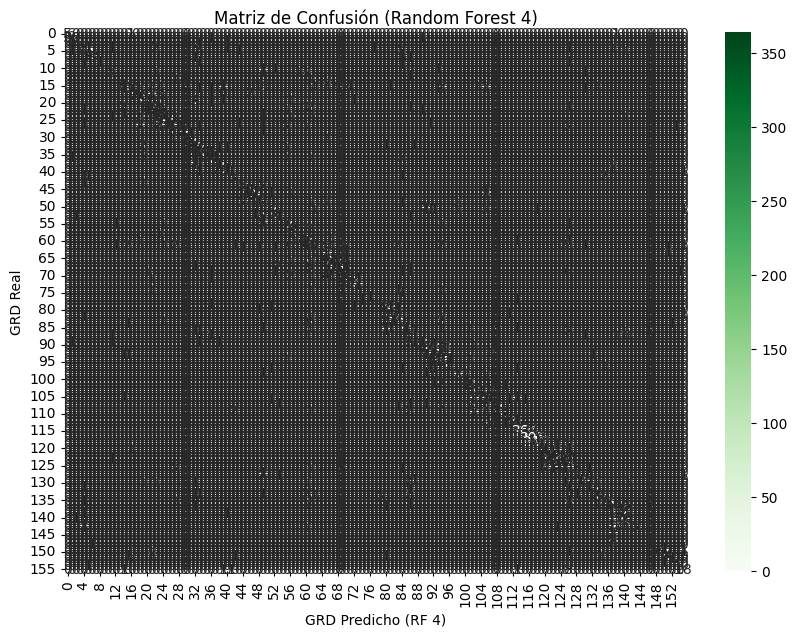

In [48]:
# Matriz de confusión
matriz_confusion_rf4 = confusion_matrix(y_test_rf4, y_pred_rf4)
plt.figure(figsize=(10,7))
sns.heatmap(matriz_confusion_rf4, annot=True, fmt="d", cmap="Greens")
plt.xlabel('GRD Predicho (RF 4)')
plt.ylabel('GRD Real')
plt.title('Matriz de Confusión (Random Forest 4)')
plt.show()

In [49]:
# Porcentaje de aciertos
porcentaje_rf4 = np.round((accuracy_score(y_test_rf4, y_pred_rf4)) * 100, decimals=2)
print(f"\nPorcentaje del modelo Random Forest 4: {porcentaje_rf4}%")

# Evaluación con métricas
medir_modelos(y_test_rf4, y_pred_rf4)


Porcentaje del modelo Random Forest 4: 81.26%
Accuracy: 81.26%
Precision (macro): 51.32%
Recall (macro): 46.47%
